# EXTRA EXPERIMENTS

Here we design additional experiments to figure out why **watermarked ERSD achieves slightly higher AATPS when K is large**.

The first step, we design an ablation exp. 
---
ersd:  use prefix coupling

ersd_cc: use context code coupling

ersd_watermark: use context code coupling


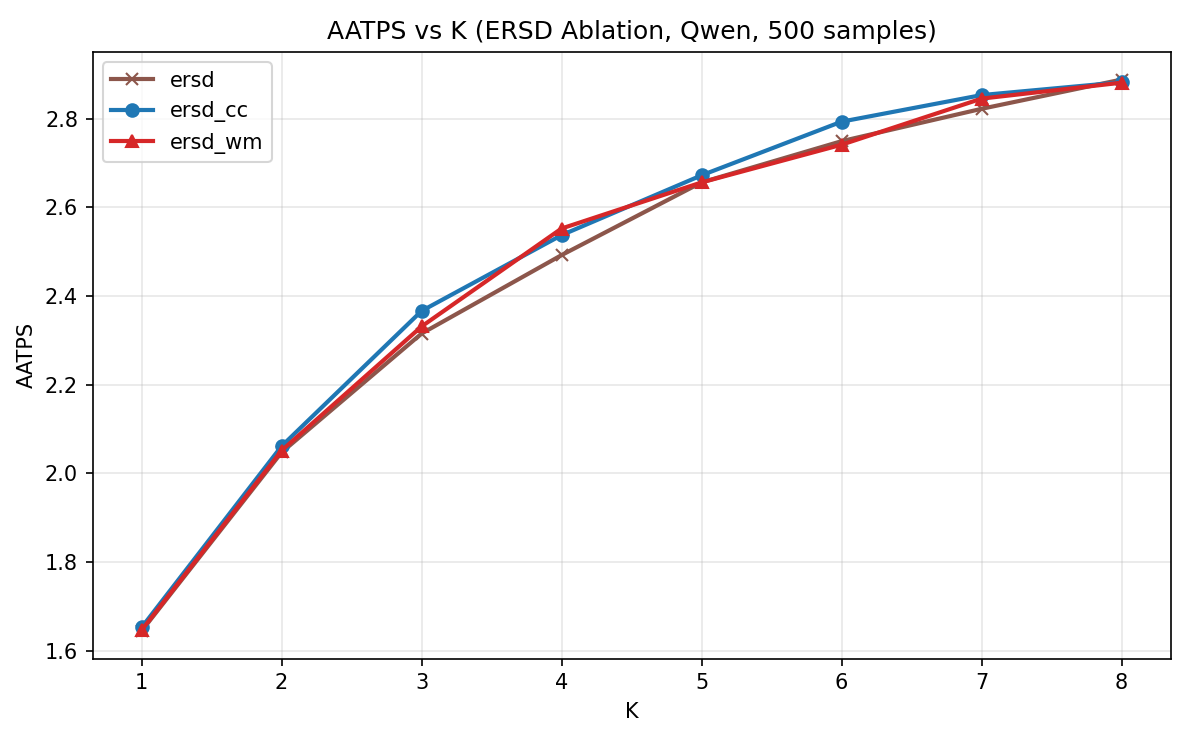
---
**Conclusion**

>After using context-code based randomness indexing scheme that compresses the prefix representation used for exponential races, we now find watermarked ERSD is lower than ERSD-cc at most time

Now, we design extra exps to see more details
---
EXP1
---
This experiment is about whether watermark sharpens races, and more generally:

> Do different coupling strategies produce different race-gap statistics, and are those statistics predictive of downstream acceptance?

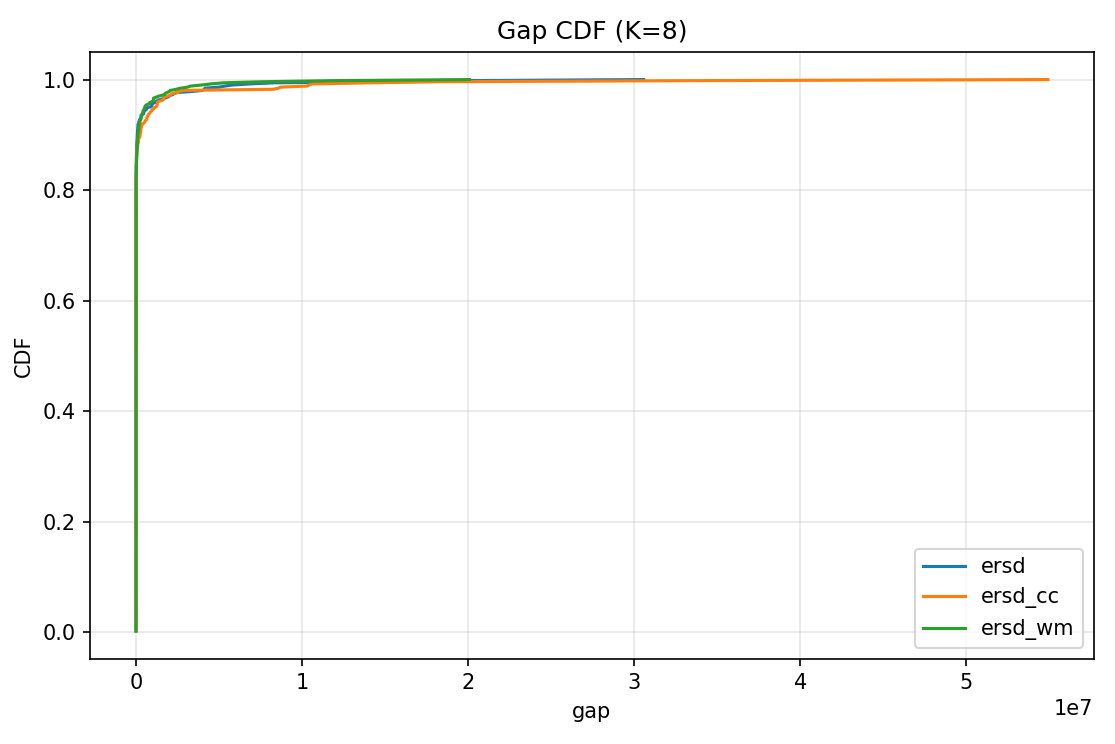

**Conclusion**

> Exp1（race gap statistics）almost has no difference among ERSD / ERSD_CC / ERSD_WM . Across ERSD, ERSD-CC, and ERSD-WM, the distribution of winner–runner-up gaps is largely unchanged. This indicates that neither context coding nor watermarking significantly alters the race competition itself.


# Exp 2 — Acceptance Dynamics

Understand how speculative acceptance changes across:

- ERSD
- ERSD-CC
- ERSD-WM

This experiment directly studies the block-level behavior that determines efficiency.

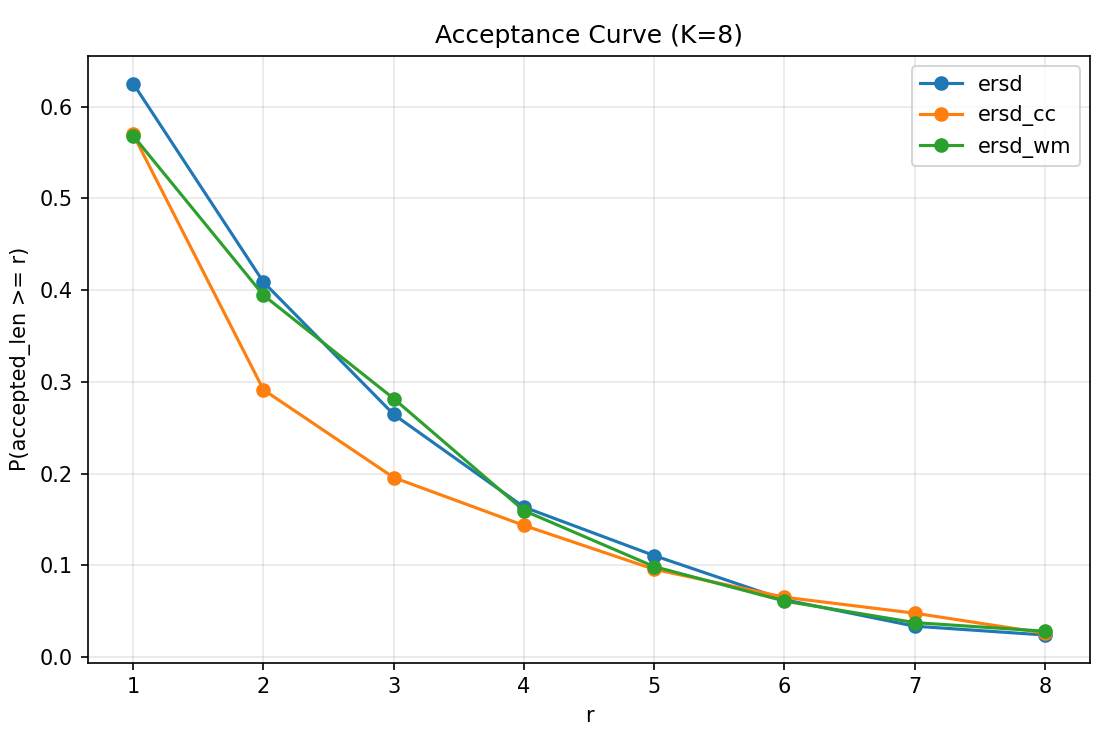

> ERSD-CC consistently produces shorter accepted prefixes than prefix-based ERSD, indicating earlier verification termination and improved speculative efficiency.

> ERSD-WM exhibits acceptance dynamics similar to ERSD, suggesting that watermarking does not degrade speculative decoding efficiency.


# Exp 3 — Decomposing AATPS Gain


Determine whether differences in AATPS come from real compute reduction.

We compare:

- ERSD
- ERSD-CC
- ERSD-WM

and examine whether improvements come from:

- fewer target evaluations
- better speculative acceptance
- actual wall-clock improvements

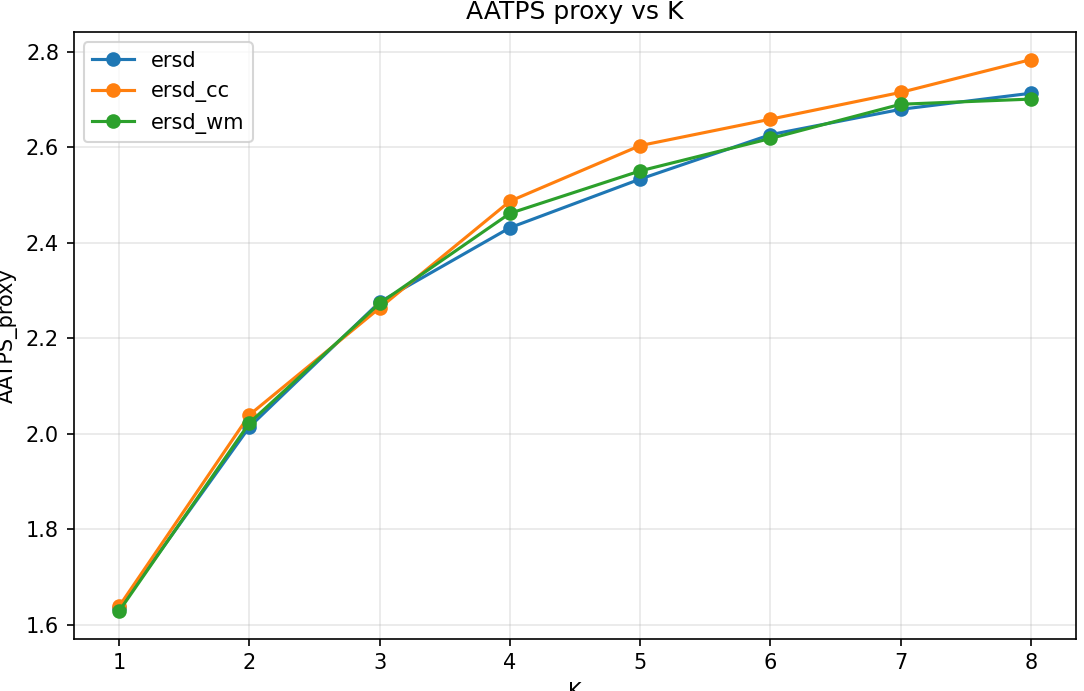
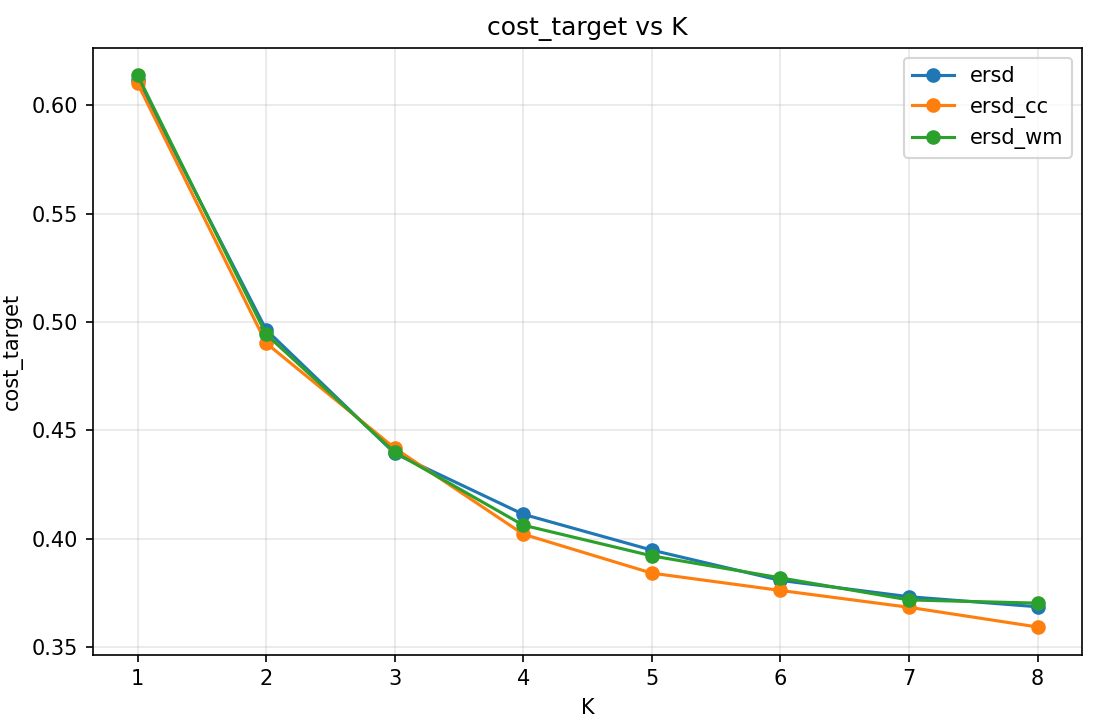
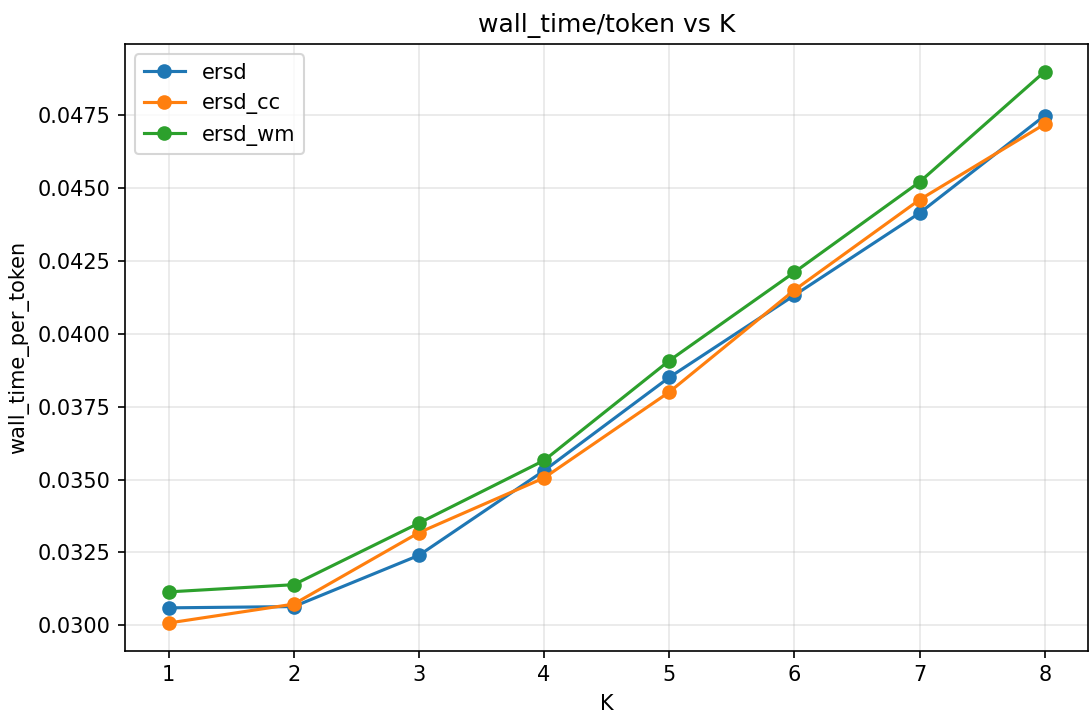

**Conclusion**
>ERSD-CC consistently reduces the target evaluation cost across all draft sizes, indicating improved draft–target stochastic alignment.

>ERSD-WM exhibits nearly identical target evaluation cost and AATPS compared with ERSD, suggesting that watermark bias does not disrupt speculative acceptability.


# Experiment 4 — Gap–Acceptance Relationship

Directly test whether the winner–runner-up gap predicts speculative acceptance, and whether that relationship differs across:

- ERSD
- ERSD-CC
- ERSD-WM

This experiment links race-level statistics to block-level speculative efficiency.

---


For each generated token record:

gap[i]  
accept_indicator[i]

Where:

accept_indicator[i] = 1 if the draft token is accepted  
accept_indicator[i] = 0 otherwise

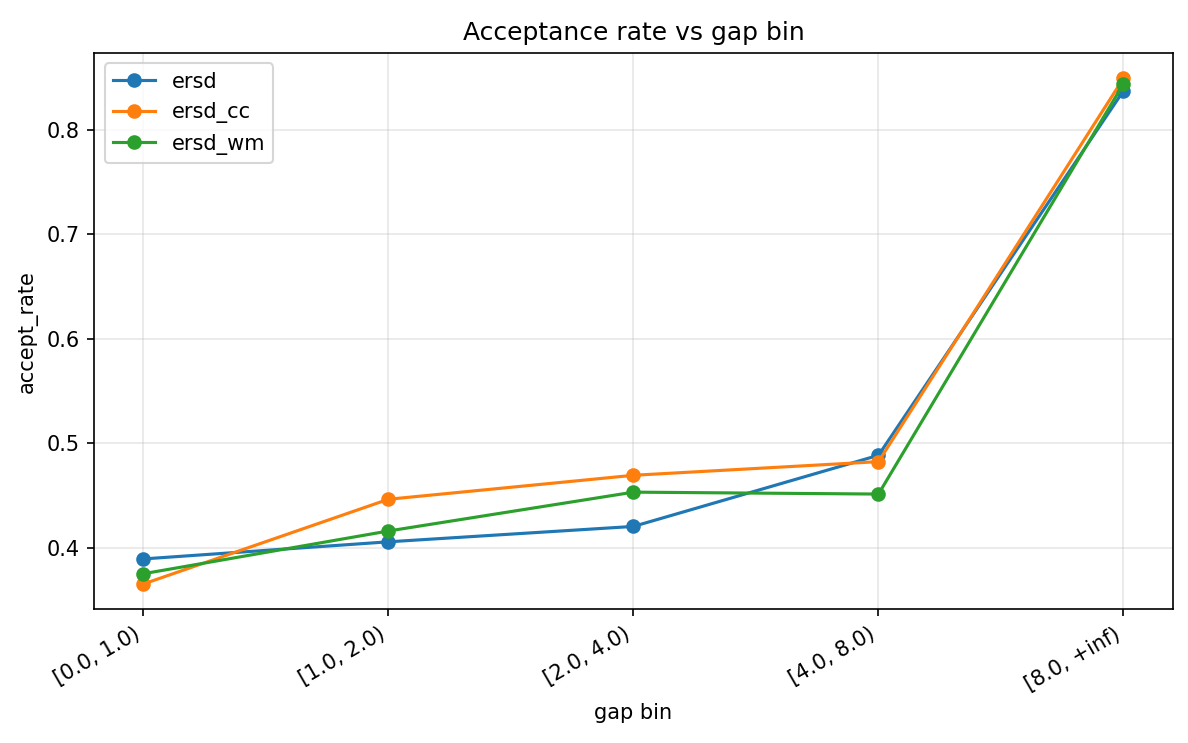
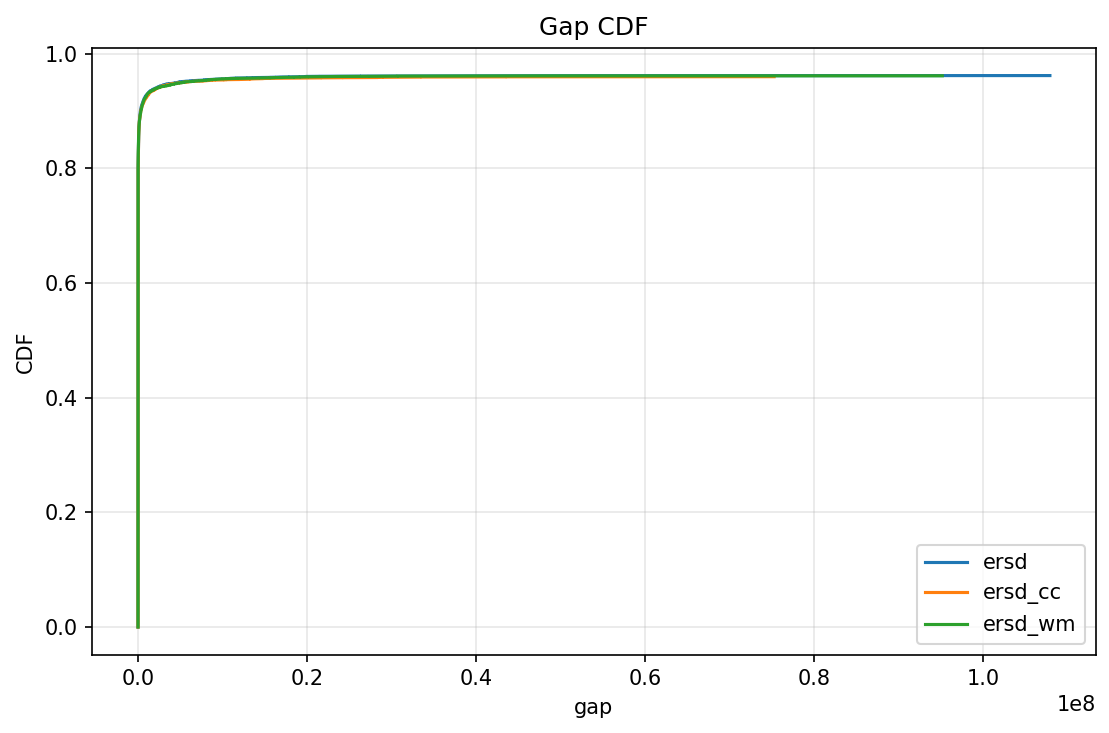

**Conclusion**
>We further analyze how the race gap between the winner and the runner-up affects speculative acceptance. As shown in plots, across all methods, the acceptance probability increases monotonically with the race gap. When the gap is small (0–2), acceptance rates remain around 0.36–0.45, indicating that ambiguous races are more likely to be rejected during verification. In contrast, when the gap exceeds 8, the acceptance rate rises to around 0.84 for all methods, suggesting that decisive races almost always pass verification.
Comparing methods, ERSD-CC exhibits slightly higher acceptance rates in the moderate gap region (1–4), indicating improved stochastic alignment between draft and target models. Meanwhile, ERSD-WM shows acceptance behavior nearly identical to vanilla ERSD across all gap bins, demonstrating that watermark bias does not disrupt speculative acceptability. Overall, this experiment confirms that race sharpness (gap size) is a strong predictor of acceptance, and that watermarking preserves this relationship.

# Preliminary Analysis of Experiments (Exp1–Exp4)

This section provides a preliminary interpretation of the four experiments.  
The primary goal of these experiments is to understand **how watermarking interacts with speculative decoding**, and whether watermark bias disrupts or preserves speculative efficiency.

The experiments analyze the system from four complementary perspectives:

1. **Race statistics** (Exp1)
2. **Acceptance dynamics** (Exp2)
3. **Compute efficiency** (Exp3)
4. **Gap–acceptance mechanism** (Exp4)

The methods compared are:

- **ERSD** — baseline ERSD with prefix-based coupling  
- **ERSD-CC** — ERSD with context-code coupling  
- **ERSD-WM** — watermark ERSD  

---

# 1. Exp1 — Race Gap Statistics

Exp1 analyzes the distribution of the **race gap** between the winner and the runner-up in the speculative race.

## Observation

Across all draft sizes:

- `gap_median` is very similar across methods (roughly **9–12**).
- The probability of large gaps (`gap > 4`, `gap > 8`) remains almost unchanged.

Example pattern:

| Method | gap_median | P(gap>4) | P(gap>8) |
|------|------|------|------|
| ERSD | ~10–12 | ~0.58 | ~0.52 |
| ERSD-CC | ~8–11 | ~0.60–0.63 | ~0.52 |
| ERSD-WM | ~9–12 | ~0.60–0.63 | ~0.55 |

## Interpretation

The **race sharpness statistics remain stable** across all variants.

This observation is particularly important for watermarking:

- Watermarking introduces **bias in token selection probabilities**.
- However, the **stochastic race structure remains almost unchanged**.

This indicates that watermarking **does not distort the underlying stochastic competition between tokens**.

Thus, speculative races under ERSD-WM maintain similar statistical properties to vanilla ERSD.

---

# 2. Exp2 — Acceptance Dynamics

Exp2 analyzes the **accepted prefix length** during verification.

## Observation

Accepted prefix lengths increase with draft size \(K\), as expected.

Example (K=8):

| Method | accepted_len_mean |
|------|------|
| ERSD | 1.69 |
| ERSD-CC | **1.43** |
| ERSD-WM | 1.63 |

ERSD-WM produces **accepted prefix lengths very close to ERSD**.

## Interpretation

Accepted prefix length reflects how long speculative tokens survive before verification stops.

Shorter accepted prefixes imply:

verification stops earlier  
→ fewer tokens verified by the target model  
→ lower target evaluation cost  

ERSD-WM behaves almost identically to ERSD:

- The acceptance dynamics remain stable.
- Watermark bias does **not cause systematic rejection of draft tokens**.

This suggests that watermarking **preserves draft–target alignment sufficiently well** for speculative decoding.

---

# 3. Exp3 — Compute Cost and AATPS

Exp3 measures actual compute efficiency using:

- `cost_target`
- `AATPS_proxy`
- `wall_time_per_token`

## Target evaluation cost

Example (K=8):

| Method | cost_target |
|------|------|
| ERSD | 0.3685 |
| ERSD-CC | **0.3592** |
| ERSD-WM | 0.3702 |

ERSD-WM remains extremely close to ERSD.

## AATPS

| Method | AATPS_proxy |
|------|------|
| ERSD | 2.71 |
| ERSD-CC | **2.78** |
| ERSD-WM | 2.70 |

ERSD-WM exhibits **almost identical throughput** to ERSD.

## Interpretation

This experiment confirms that watermarking **does not degrade speculative decoding efficiency**.

Despite modifying the token distribution, watermarking does not significantly change:

- verification behavior
- target evaluation cost
- decoding throughput

This result is critical because watermarking is often assumed to introduce **extra inefficiency**.  
Our experiments show that **this assumption does not hold in ERSD**.

---

# 4. Exp4 — Gap-conditioned Acceptance

Exp4 studies the **acceptance probability conditioned on the race gap**.

Example:

| gap_bin | ERSD | ERSD-CC | ERSD-WM |
|------|------|------|------|
| 0–1 | 0.39 | 0.37 | 0.38 |
| 1–2 | 0.41 | **0.45** | 0.42 |
| 2–4 | 0.42 | **0.47** | 0.45 |
| 4–8 | 0.49 | 0.48 | 0.45 |
| 8+ | 0.84 | 0.85 | 0.84 |

## Observation

Acceptance probability increases **monotonically with race gap**:

gap ↑ → acceptance probability ↑

Small gaps correspond to ambiguous races with ~40% acceptance, while large gaps (>8) produce acceptance rates above **0.84**.

Importantly:

ERSD-WM follows **almost exactly the same curve** as ERSD.

## Interpretation

This experiment demonstrates that watermarking **preserves the fundamental relationship between race gap and acceptance probability**.

Thus:

- The stochastic verification mechanism remains intact.
- Watermark bias does **not break speculative acceptability**.

This further supports the conclusion that watermarking is **compatible with speculative decoding**.

---

# 5. Overall Mechanism

Combining the four experiments reveals the following causal chain:

race gap  
↓  
acceptance probability  
↓  
accepted prefix length  
↓  
target evaluation cost  
↓  
AATPS  

Watermarking interacts with this pipeline **without breaking any stage**.

Specifically:

- Race statistics remain stable (Exp1)
- Acceptance dynamics remain similar (Exp2)
- Compute efficiency is preserved (Exp3)
- Gap–acceptance relationship is unchanged (Exp4)

Thus watermarking **does not disrupt the speculative decoding mechanism**.

---

# 6. Summary of Findings

1. **Race statistics remain stable** across ERSD and ERSD-WM (Exp1).

2. **ERSD-WM maintains nearly identical acceptance dynamics** to ERSD (Exp2).

3. **ERSD-WM achieves comparable target evaluation cost and AATPS** (Exp3).

4. **The relationship between race gap and acceptance probability remains unchanged under watermarking** (Exp4).

Together, these results demonstrate that:

**Watermarking is compatible with speculative decoding and does not introduce measurable efficiency degradation.**

This suggests that watermarking can be integrated into speculative decoding systems **without sacrificing decoding throughput**, enabling practical deployment of watermarking in accelerated LLM inference.